### Part 1 - General view
This part of the notebook contains preparation for gene pleiotropy analysis and initial data analysis of the mouse and human genotype-phenotypic association database (human_mouse_GPO_mono.tsv).

In [72]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr, kendalltau
from collections import Counter

In [73]:
pd.set_option('display.max_rows', 25)

#### Prepare the database

In [74]:
import shutil

shutil.copyfile('./databases/tmp_data/human_mouse_GPO_mono.tsv', './databases/human_mouse_GPO_mono.tsv')
shutil.copyfile('./databases/tmp_data/human_mouse_GPO.tsv', './databases/human_mouse_GPO.tsv')

'./databases/human_mouse_GPO.tsv'

In [75]:
# importing the main table created earlier in dataset_consolidation.ipynb

def converter(x):
    if x != '':
        return x.split(',')

all_HPO_table = pd.read_csv(os.path.join('.', 'databases', 'human_mouse_GPO.tsv'),
                   delimiter='\t',
                   converters={'MPO_lower': converter, 'HPO_lower': converter, 'MP_system_level': converter,
                               'HP_system_level': converter, 'MP_from_HP_system_level': converter},
                   usecols=lambda col: col != 'MP_HMD')

# rename the columns as we prefer
all_HPO_table = all_HPO_table.rename(columns={
    'MPO_lower': 'MP_low_level',
    'HPO_lower': 'HP_low_level',
    'MP_system_level': 'MP_high_level',
    'HP_system_level': 'HP_high_level_human',
    'MP_from_HP_system_level': 'HP_high_level'
})
all_HPO_table

,gene_human,entrez_id_human,gene_mouse,MGI,MP_PhenoGeno,HP_genes_to_phenotype,MP_high_level,HP_high_level_human,HP_high_level,MP_low_level,HP_low_level
0,A1BG,1,A1bg,MGI:2152878,NaN,NaN,None,None,None,None,None
1,A1CF,29974,A1cf,MGI:1917115,"MP:0005633,MP:0005140,MP:0005561,MP:0000352,MP...",NaN,"[MP:0005369, MP:0005386, MP:0005397, MP:000537...",None,None,"[MP:0005633, MP:0005140, MP:0005561, MP:000035...",None
2,A2M,2,A2m,MGI:2449119,NaN,NaN,None,None,None,None,None
3,A3GALT2,127550,A3galt2,MGI:2685279,MP:0002169,NaN,None,None,None,None,None
4,A4GALT,53947,A4galt,MGI:3512453,"MP:0009747,MP:0009767,MP:0008874",NaN,"[MP:0005386, MP:0005376]",None,None,"[MP:0009747, MP:0009767, MP:0008874]",None
...,...,...,...,...,...,...,...,...,...,...,...
29594,ZYG11A,440590,Zyg11a,MGI:2446208,NaN,NaN,None,None,None,None,None
29595,ZYG11B,79699,Zyg11b,MGI:2685277,"MP:0011110,MP:0001402,MP:0001417",NaN,[MP:0005386],None,None,"[MP:0001402, MP:0001417]",None
29596,ZYX,7791,Zyx,MGI:103072,"MP:0011707,MP:0003566,MP:0011709,MP:0002169,MP...",NaN,[MP:0005384],None,None,"[MP:0011709, MP:0011707, MP:0003566, MP:0000358]",None
29597,ZZEF1,23140,Zzef1,MGI:2444286,"MP:0000186,MP:0005561,MP:0005179,MP:0005627,MP...",NaN,"[MP:0010771, MP:0005382, MP:0005376, MP:000536...",None,None,"[MP:0000186, MP:0005627, MP:0005179, MP:000556...",None


Here, we will subset the data to keep 1 entry per each organism, removing orthology for those genes that have multiple orthologs

In [76]:
single_copy_data = pd.read_csv('./databases/human_mouse_GPO_mono.tsv', sep='\t')
single_copy_data.head()

,gene_human,entrez_id_human,gene_mouse,MGI,MP_HMD,MP_PhenoGeno,HP_genes_to_phenotype,MP_system_level,HP_system_level,MP_from_HP_system_level,MPO_lower,HPO_lower
0,A1BG,1,A1bg,MGI:2152878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A1CF,29974,A1cf,MGI:1917115,NaN,"MP:0005633,MP:0005140,MP:0005561,MP:0000352,MP...",NaN,"MP:0005369,MP:0005386,MP:0005397,MP:0005378,MP...",NaN,NaN,"MP:0005633,MP:0005140,MP:0005561,MP:0000352,MP...",NaN
2,A2M,2,A2m,MGI:2449119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A3GALT2,127550,A3galt2,MGI:2685279,NaN,MP:0002169,NaN,NaN,NaN,NaN,NaN,NaN
4,A4GALT,53947,A4galt,MGI:3512453,NaN,"MP:0009747,MP:0009767,MP:0008874",NaN,"MP:0005386,MP:0005376",NaN,NaN,"MP:0009747,MP:0009767,MP:0008874",NaN


In [77]:
human_sco = list(single_copy_data['gene_human'])
mouse_sco = list(single_copy_data['gene_mouse'])

In [78]:
hpo_only_table = all_HPO_table.loc[[x not in human_sco for x in all_HPO_table['gene_human']]]
hpo_only_table = hpo_only_table.drop_duplicates(subset = ['gene_human'])
hpo_only_table = hpo_only_table.dropna(subset=['HP_high_level'])
hpo_only_table['gene_mouse'], hpo_only_table['MGI'], hpo_only_table['MP_high_level'], hpo_only_table['MP_low_level'] = None, None, None, None
hpo_only_table.shape

(228, 11)

In [79]:
mgd_only_table = all_HPO_table.loc[[x not in mouse_sco for x in all_HPO_table['gene_mouse']]]
mgd_only_table = mgd_only_table.drop_duplicates(subset = ['gene_mouse'])
mgd_only_table = mgd_only_table.dropna(subset=['MP_high_level'])
mgd_only_table['gene_human'], mgd_only_table['entrez_id_human'], mgd_only_table['HP_high_level'], mgd_only_table['HP_low_level'], mgd_only_table['HP_high_level_human'] = None, None, None, None, None
mgd_only_table.shape

(734, 11)

In [80]:
base_HPO_table = all_HPO_table.loc[[x in human_sco for x in all_HPO_table['gene_human']]]
base_HPO_table.shape

(16983, 11)

In [81]:
main_HPO_table = pd.concat([base_HPO_table, hpo_only_table, mgd_only_table])
main_HPO_table.shape

(17945, 11)

Returning back to the main part of the analysis

In [82]:
# adding gene IDs for mice

mgi_gene = pd.read_csv(os.path.join('.', 'databases', 'MGI_to_ID.rpt'), delimiter='\t', usecols=range(6))
main_HPO_table = main_HPO_table.merge(mgi_gene, how='left', left_on='MGI', right_on='1. MGI accession id')
main_HPO_table = main_HPO_table.rename(columns={'6. Entrez gene id': 'entrez_id_mouse'})
main_HPO_table = main_HPO_table.loc[:, ['gene_human', 'entrez_id_human', 'gene_mouse', 'MGI', 'entrez_id_mouse', 'MP_low_level',
                                         'HP_low_level', 'MP_high_level', 'HP_high_level_human', 'HP_high_level']].copy()
main_HPO_table

,gene_human,entrez_id_human,gene_mouse,MGI,entrez_id_mouse,MP_low_level,HP_low_level,MP_high_level,HP_high_level_human,HP_high_level
0,A1BG,1,A1bg,MGI:2152878,NaN,None,None,None,None,None
1,A1CF,29974,A1cf,MGI:1917115,NaN,"[MP:0005633, MP:0005140, MP:0005561, MP:000035...",None,"[MP:0005369, MP:0005386, MP:0005397, MP:000537...",None,None
2,A2M,2,A2m,MGI:2449119,NaN,None,None,None,None,None
3,A3GALT2,127550,A3galt2,MGI:2685279,NaN,None,None,None,None,None
4,A4GALT,53947,A4galt,MGI:3512453,NaN,"[MP:0009747, MP:0009767, MP:0008874]",None,"[MP:0005386, MP:0005376]",None,None
...,...,...,...,...,...,...,...,...,...,...
17940,None,None,Zfp746,MGI:1916478,NaN,"[MP:0004502, MP:0010124, MP:0003961, MP:001002...",None,"[MP:0005379, MP:0005376, MP:0002006, MP:001077...",None,None
17941,None,None,Zfp60,MGI:99207,NaN,"[MP:0000745, MP:0002968, MP:0004924, MP:000139...",None,"[MP:0005386, MP:0005376]",None,None
17942,None,None,Zng1,MGI:2385089,NaN,"[MP:0011493, MP:0000519, MP:0011425, MP:000051...",None,[MP:0005367],None,None
17943,None,None,Zrsr2,MGI:103287,NaN,"[MP:0000266, MP:0000274, MP:0000219, MP:000501...",None,"[MP:0005385, MP:0005387, MP:0005389, MP:000539...",None,None


In [83]:
# create new columns with the number of HPO terms 
main_HPO_table.loc[:, 'HP_count'] = main_HPO_table['HP_low_level'].apply(lambda x: len(x) if x is not None else None)
main_HPO_table.loc[:, 'HP_high_count'] = main_HPO_table['HP_high_level'].apply(lambda x: len(x) if x is not None else None)

# create new columns with the number of MPO terms
main_HPO_table.loc[:, 'MP_count'] = main_HPO_table['MP_low_level'].apply(lambda x: len(x) if x is not None else None)
main_HPO_table.loc[:, 'MP_high_count'] = main_HPO_table['MP_high_level'].apply(lambda x: len(x) if x is not None else None)

In [84]:
# adding GWAS database

base_GWAS_table = pd.read_csv(os.path.join('.', 'databases', 'non_hla_panukb_finngen_pleiotropy_final.tsv'), delimiter='\t')
base_GWAS_table = base_GWAS_table[~((base_GWAS_table['gene_name'] == '.'))] # drop the line with empty values
base_GWAS_table


,gene_name,fg_pleio_degree_finemap,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide,fg_pleio_degree
0,TTLL10-AS1,1.0,NaN,NaN,1.0,NaN
1,SDF4,1.0,NaN,NaN,NaN,NaN
2,ACAP3,1.0,NaN,NaN,1.0,2.0
3,DVL1,2.0,NaN,NaN,1.0,NaN
4,MXRA8,1.0,NaN,NaN,1.0,2.0
...,...,...,...,...,...,...
21618,RNU6ATAC28P,NaN,NaN,NaN,NaN,1.0
21619,AC004166.6,NaN,NaN,NaN,NaN,1.0
21620,ANAPC16,NaN,NaN,NaN,NaN,1.0
21621,C10orf55,NaN,NaN,NaN,NaN,1.0


In [85]:
sum(base_GWAS_table['fg_pleio_degree'] > 0)

7919

In [86]:
np.nansum(base_GWAS_table['fg_pleio_degree'])

np.float64(14898.0)

In [87]:
Counter(base_GWAS_table['gene_name'] == np.nan)

Counter({False: 21622})

In [88]:
# merge the datasets

main_HPO_table = main_HPO_table.merge(base_GWAS_table, how='outer', left_on='gene_human', right_on='gene_name')
main_HPO_table

,gene_human,entrez_id_human,gene_mouse,MGI,entrez_id_mouse,MP_low_level,HP_low_level,MP_high_level,HP_high_level_human,HP_high_level,HP_count,HP_high_count,MP_count,MP_high_count,gene_name,fg_pleio_degree_finemap,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide,fg_pleio_degree
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7SK,NaN,NaN,NaN,1.0,NaN
1,A1BG,1,A1bg,MGI:2152878,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1CF,29974,A1cf,MGI:1917115,NaN,"[MP:0005633, MP:0005140, MP:0005561, MP:000035...",None,"[MP:0005369, MP:0005386, MP:0005397, MP:000537...",None,None,NaN,NaN,8.0,7.0,A1CF,NaN,3.0,3.0,3.0,NaN
3,A2M,2,A2m,MGI:2449119,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A2ML1-AS1,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30632,None,None,Zfp746,MGI:1916478,NaN,"[MP:0004502, MP:0010124, MP:0003961, MP:001002...",None,"[MP:0005379, MP:0005376, MP:0002006, MP:001077...",None,None,NaN,NaN,7.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
30633,None,None,Zfp60,MGI:99207,NaN,"[MP:0000745, MP:0002968, MP:0004924, MP:000139...",None,"[MP:0005386, MP:0005376]",None,None,NaN,NaN,5.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
30634,None,None,Zng1,MGI:2385089,NaN,"[MP:0011493, MP:0000519, MP:0011425, MP:000051...",None,[MP:0005367],None,None,NaN,NaN,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
30635,None,None,Zrsr2,MGI:103287,NaN,"[MP:0000266, MP:0000274, MP:0000219, MP:000501...",None,"[MP:0005385, MP:0005387, MP:0005389, MP:000539...",None,None,NaN,NaN,7.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
# add the missing gene names from the GWAS data (gene_human)

main_HPO_table['gene_human'] = main_HPO_table['gene_human'].fillna(main_HPO_table['gene_name'])

In [90]:
# remove columns with gene names from the GWAS dataset

main_HPO_table.drop(['gene_name'], axis=1, inplace=True)
main_HPO_table

,gene_human,entrez_id_human,gene_mouse,MGI,entrez_id_mouse,MP_low_level,HP_low_level,MP_high_level,HP_high_level_human,HP_high_level,HP_count,HP_high_count,MP_count,MP_high_count,fg_pleio_degree_finemap,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide,fg_pleio_degree
0,7SK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
1,A1BG,1,A1bg,MGI:2152878,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1CF,29974,A1cf,MGI:1917115,NaN,"[MP:0005633, MP:0005140, MP:0005561, MP:000035...",None,"[MP:0005369, MP:0005386, MP:0005397, MP:000537...",None,None,NaN,NaN,8.0,7.0,NaN,3.0,3.0,3.0,NaN
3,A2M,2,A2m,MGI:2449119,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A2ML1-AS1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30632,NaN,None,Zfp746,MGI:1916478,NaN,"[MP:0004502, MP:0010124, MP:0003961, MP:001002...",None,"[MP:0005379, MP:0005376, MP:0002006, MP:001077...",None,None,NaN,NaN,7.0,8.0,NaN,NaN,NaN,NaN,NaN
30633,NaN,None,Zfp60,MGI:99207,NaN,"[MP:0000745, MP:0002968, MP:0004924, MP:000139...",None,"[MP:0005386, MP:0005376]",None,None,NaN,NaN,5.0,2.0,NaN,NaN,NaN,NaN,NaN
30634,NaN,None,Zng1,MGI:2385089,NaN,"[MP:0011493, MP:0000519, MP:0011425, MP:000051...",None,[MP:0005367],None,None,NaN,NaN,6.0,1.0,NaN,NaN,NaN,NaN,NaN
30635,NaN,None,Zrsr2,MGI:103287,NaN,"[MP:0000266, MP:0000274, MP:0000219, MP:000501...",None,"[MP:0005385, MP:0005387, MP:0005389, MP:000539...",None,None,NaN,NaN,7.0,6.0,NaN,NaN,NaN,NaN,NaN


In [91]:
# adding cluster data

cluster_data = pd.read_csv(os.path.join('.', 'databases', 'human_mouse_gene_to_cluster.tsv'),
                           delimiter='\t', 
                           usecols=['gene_human', 'n_clusters_m', 'n_clusters_h'])
cluster_data

,gene_human,n_clusters_m,n_clusters_h
0,A1BG,NaN,NaN
1,A1CF,152.0,NaN
2,A2M,NaN,NaN
3,A3GALT2,NaN,NaN
4,A4GALT,3.0,NaN
...,...,...,...
16978,ZYG11A,NaN,NaN
16979,ZYG11B,2.0,NaN
16980,ZYX,4.0,NaN
16981,ZZEF1,10.0,NaN


In [92]:
main_HPO_table = pd.merge(main_HPO_table, cluster_data, left_on=['gene_human'], right_on=['gene_human'], how='outer')
main_HPO_table

,gene_human,entrez_id_human,gene_mouse,MGI,entrez_id_mouse,MP_low_level,HP_low_level,MP_high_level,HP_high_level_human,HP_high_level,...,HP_high_count,MP_count,MP_high_count,fg_pleio_degree_finemap,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide,fg_pleio_degree,n_clusters_m,n_clusters_h
0,7SK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
1,A1BG,1,A1bg,MGI:2152878,NaN,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1CF,29974,A1cf,MGI:1917115,NaN,"[MP:0005633, MP:0005140, MP:0005561, MP:000035...",None,"[MP:0005369, MP:0005386, MP:0005397, MP:000537...",None,None,...,NaN,8.0,7.0,NaN,3.0,3.0,3.0,NaN,152.0,NaN
3,A2M,2,A2m,MGI:2449119,NaN,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A2ML1-AS1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30632,NaN,None,Zfp746,MGI:1916478,NaN,"[MP:0004502, MP:0010124, MP:0003961, MP:001002...",None,"[MP:0005379, MP:0005376, MP:0002006, MP:001077...",None,None,...,NaN,7.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30633,NaN,None,Zfp60,MGI:99207,NaN,"[MP:0000745, MP:0002968, MP:0004924, MP:000139...",None,"[MP:0005386, MP:0005376]",None,None,...,NaN,5.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30634,NaN,None,Zng1,MGI:2385089,NaN,"[MP:0011493, MP:0000519, MP:0011425, MP:000051...",None,[MP:0005367],None,None,...,NaN,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30635,NaN,None,Zrsr2,MGI:103287,NaN,"[MP:0000266, MP:0000274, MP:0000219, MP:000501...",None,"[MP:0005385, MP:0005387, MP:0005389, MP:000539...",None,None,...,NaN,7.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Evaluate the correlation between the number of terms in mouse and human genes

In [93]:
# drop NA in HP_high_count and MP_high_count
main_HPO_table_not_na = main_HPO_table.dropna(subset=['HP_high_count', 'MP_high_count'])

# drop NA in HP_high_count and pleio_degree
main_HPO_table_GWAS_not_na = main_HPO_table.dropna(subset=['HP_high_count', 'pleio_degree'])

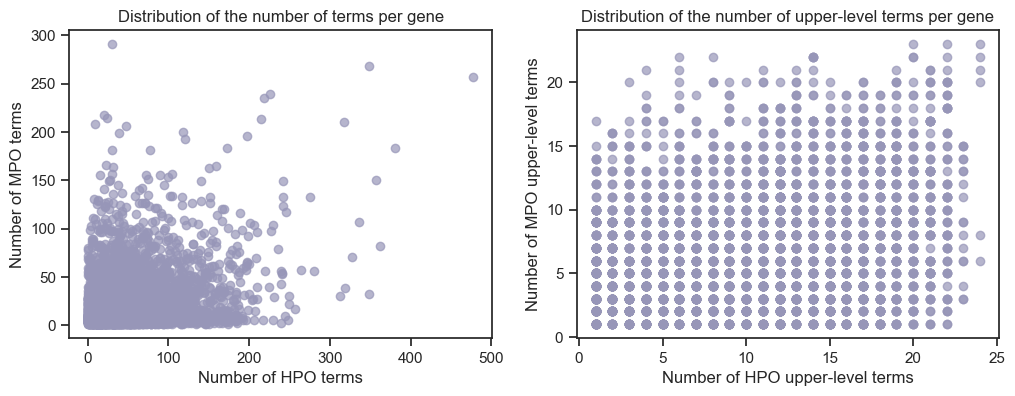

In [94]:
# look at the distribution of the number of terms and system terms per gene in mice and humans

x_low = main_HPO_table_not_na['HP_count']
y_low = main_HPO_table_not_na['MP_count']

x_high = main_HPO_table_not_na['HP_high_count']
y_high = main_HPO_table_not_na['MP_high_count']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(x_low, y_low, color='#9796b8', alpha=0.7)
ax1.set_xlabel('Number of HPO terms')
ax1.set_ylabel('Number of MPO terms')
ax1.set_title('Distribution of the number of terms per gene')

ax2.scatter(x_high, y_high, color='#9796b8', alpha=0.7)
ax2.set_xlabel('Number of HPO upper-level terms')
ax2.set_ylabel('Number of MPO upper-level terms')
ax2.set_title('Distribution of the number of upper-level terms per gene')

plt.savefig(os.path.join('.', 'pictures', 'plei_02_distribution_scatter.png'), dpi=300, bbox_inches='tight')

plt.show()

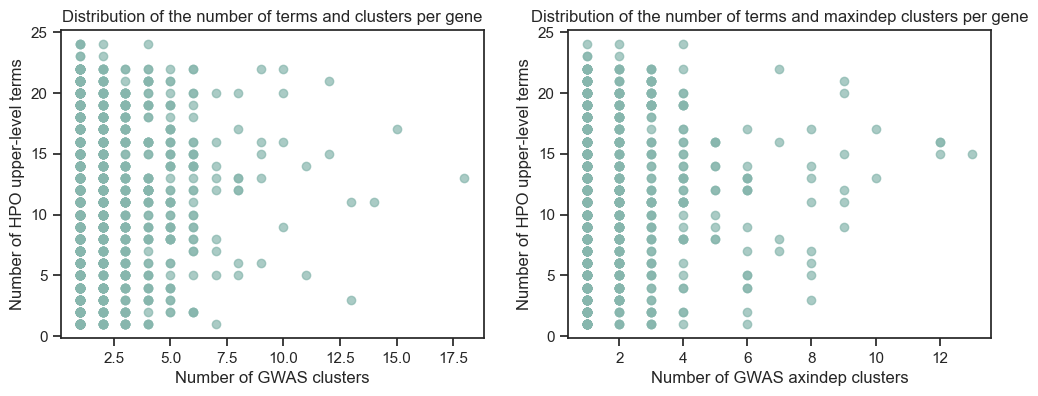

In [95]:
# look at the distribution of the number of system terms and degree of pleiotropy (GWAS)

x_pleio = main_HPO_table_not_na['pleio_degree']
y_pleio = main_HPO_table_not_na['HP_high_count']

x_maxindep = main_HPO_table_not_na['pleio_degree_maxindep']
y_maxindep = main_HPO_table_not_na['HP_high_count']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(x_pleio, y_pleio, color='#87b6ad', alpha=0.7)
ax1.set_xlabel('Number of GWAS clusters')
ax1.set_ylabel('Number of HPO upper-level terms')
ax1.set_title('Distribution of the number of terms and clusters per gene')

ax2.scatter(x_maxindep, y_maxindep, color='#87b6ad', alpha=0.7)
ax2.set_xlabel('Number of GWAS axindep clusters')
ax2.set_ylabel('Number of HPO upper-level terms')
ax2.set_title('Distribution of the number of terms and maxindep clusters per gene')

plt.savefig(os.path.join('.', 'pictures', 'plei_03_distribution_scatter.png'), dpi=300, bbox_inches='tight')

plt.show()

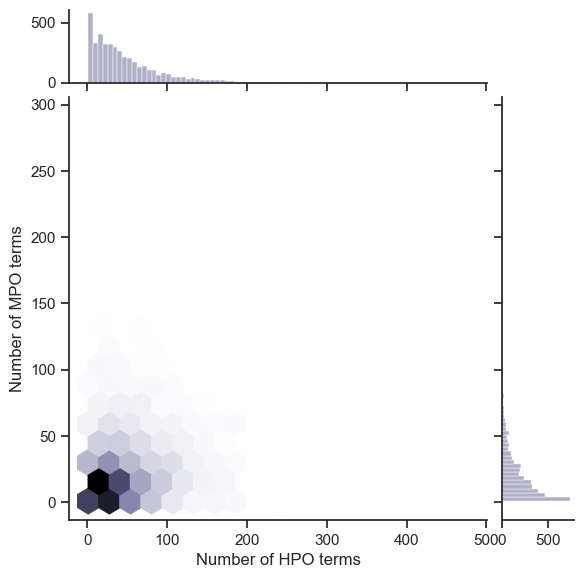

In [96]:
# look at the distribution of the number of terms per gene in mice and humans

sns.set_theme(style="ticks")

x_low = main_HPO_table_not_na['HP_count']
y_low = main_HPO_table_not_na['MP_count']

g = sns.jointplot(x=x_low, y=y_low, kind='hex', color="#9796b8", gridsize=18, marginal_ticks=True)

g.set_axis_labels(xlabel='Number of HPO terms', ylabel='Number of MPO terms')

plt.savefig(os.path.join('.', 'pictures', 'plei_04_hexbin_low.png'), dpi=300, bbox_inches='tight')

plt.show()

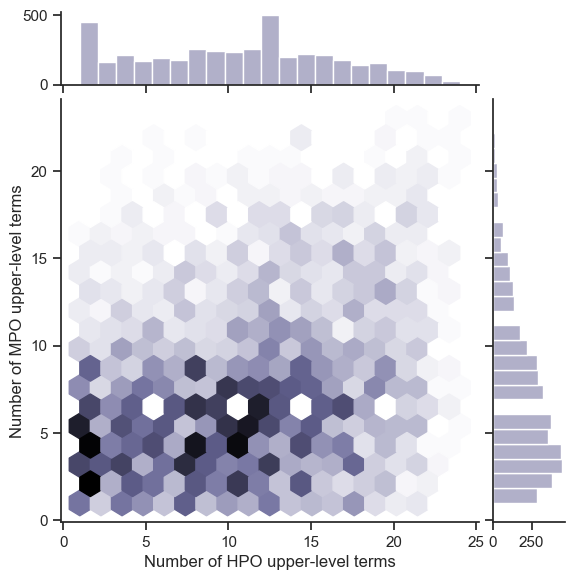

In [97]:
# look at the distribution of the number of upper-level terms per gene in mice and humans 

sns.set_theme(style="ticks")

y_high = main_HPO_table_not_na['MP_high_count']
x_high = main_HPO_table_not_na['HP_high_count']

g = sns.jointplot(x=x_high, y=y_high, kind='hex', color="#9796b8", gridsize=18, marginal_ticks=True)

g.set_axis_labels(xlabel='Number of HPO upper-level terms', ylabel='Number of MPO upper-level terms')

plt.savefig(os.path.join('.', 'pictures', 'plei_05_hexbin_upper.png'), dpi=300, bbox_inches='tight')

plt.show()

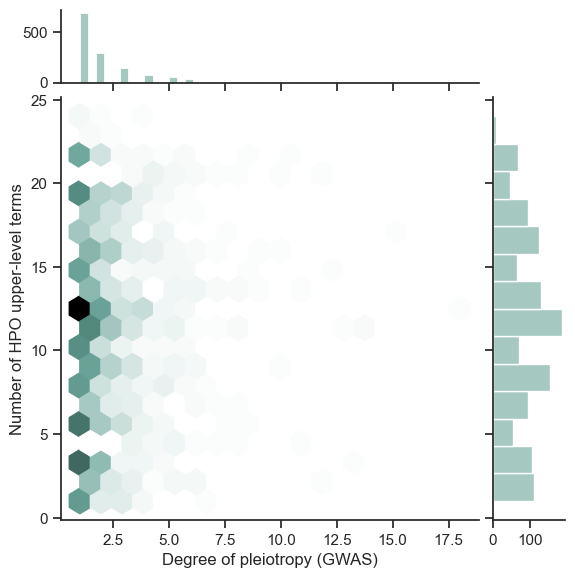

In [98]:
# look at the distribution of the number of system terms and degree of pleiotropy (GWAS)

sns.set_theme(style="ticks")

x = main_HPO_table_GWAS_not_na['pleio_degree']
y = main_HPO_table_GWAS_not_na['HP_high_count']

g = sns.jointplot(x=x, y=y, kind='hex', color="#87b6ad", gridsize=18, marginal_ticks=True)

g.set_axis_labels(xlabel='Degree of pleiotropy (GWAS)', ylabel='Number of HPO upper-level terms')

plt.savefig(os.path.join('.', 'pictures', 'plei_06_distribution_hexbin_HPO-GWAS.png'), dpi=300)

plt.show()

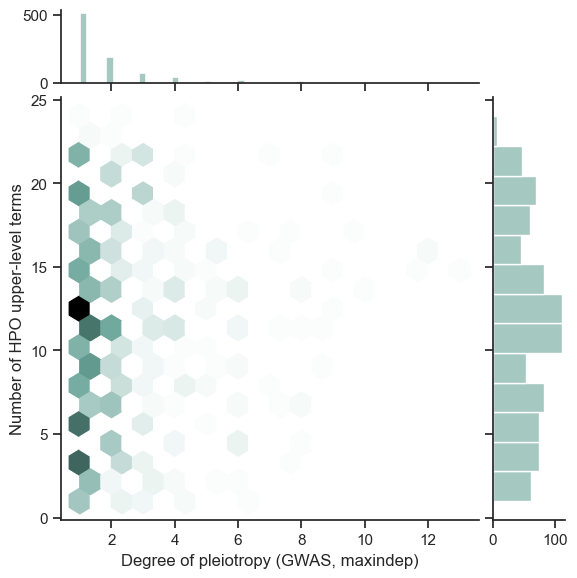

In [99]:
# look at the distribution of the number of system terms and degree of pleiotropy (GWAS)

sns.set_theme(style="ticks")

x = main_HPO_table_GWAS_not_na['pleio_degree_maxindep']
y = main_HPO_table_GWAS_not_na['HP_high_count']

g = sns.jointplot(x=x, y=y, kind='hex', color="#87b6ad", gridsize=18, marginal_ticks=True)

g.set_axis_labels(xlabel='Degree of pleiotropy (GWAS, maxindep)', ylabel='Number of HPO upper-level terms')

plt.savefig(os.path.join('.', 'pictures', 'plei_07_distribution_hexbin_HPO-GWAS.png'), dpi=300)

plt.show()

In [100]:
# find the correlation of the number of upper-level terms

y = main_HPO_table_not_na['MP_high_count']
x = main_HPO_table_not_na['HP_high_count']

corr_k, p_value_k = kendalltau(x, y)
corr_s, p_value_s = spearmanr(x, y)

print("Kendall's tau coefficient: {:.2f}, p-value: {:.3f}".format(corr_k, p_value_k))
print("Spearman's rank correlation coefficient: {:.2f}, p-value: {:.3f}".format(corr_s, p_value_s))

Kendall's tau coefficient: 0.18, p-value: 0.000
Spearman's rank correlation coefficient: 0.26, p-value: 0.000


In [101]:
# find the correlation of the number of low-level terms

y = main_HPO_table_not_na['MP_count']
x = main_HPO_table_not_na['HP_count']

corr_k, p_value_k = kendalltau(x, y)
corr_s, p_value_s = spearmanr(x, y)

print("Kendall's tau coefficient: {:.2f}, p-value: {:.3f}".format(corr_k, p_value_k))
print("Spearman's rank correlation coefficient: {:.2f}, p-value: {:.3f}".format(corr_s, p_value_s))

Kendall's tau coefficient: 0.16, p-value: 0.000
Spearman's rank correlation coefficient: 0.24, p-value: 0.000


In [102]:
# find the correlation of the number of upper-level HPO-terms and degree of pleiotropy (GWAS)

x = main_HPO_table_GWAS_not_na['pleio_degree']
y = main_HPO_table_GWAS_not_na['HP_high_count']

corr_k, p_value_k = kendalltau(x, y)
corr_s, p_value_s = spearmanr(x, y)

print("Kendall's tau coefficient: {:.2f}, p-value: {:.3f}".format(corr_k, p_value_k))
print("Spearman's rank correlation coefficient: {:.2f}, p-value: {:.3f}".format(corr_s, p_value_s))

Kendall's tau coefficient: 0.04, p-value: 0.069
Spearman's rank correlation coefficient: 0.05, p-value: 0.070


In [103]:
# find the correlation of the number of upper-level HPO-terms and degree of pleiotropy (GWAS, maxindep)

x = main_HPO_table_GWAS_not_na['pleio_degree_maxindep']
y = main_HPO_table_GWAS_not_na['HP_high_count']

corr_k, p_value_k = kendalltau(x, y)
corr_s, p_value_s = spearmanr(x, y)

print("Kendall's tau coefficient: {:.2f}, p-value: {:.3f}".format(corr_k, p_value_k))
print("Spearman's rank correlation coefficient: {:.2f}, p-value: {:.3f}".format(corr_s, p_value_s))

Kendall's tau coefficient: nan, p-value: nan
Spearman's rank correlation coefficient: nan, p-value: nan


### Part 2 - Pleiotropy group analyses
This part of the notebook contains:
+ an analysis of the distribution of the number of HPO, MPO terms and GWAS clusters per gene
+ splitting all genes into pleiotropy groups
+ analysing various metrics in these groups (expression level, evolutionary conservatism, number of protein-protein interactions and positive selection traits)

#### Grouping of genes by pleiotropy
Look at the distribution of the number of HPO, MPO and GWAS cluster terms per gene and divide all genes into pleiotropy groups.

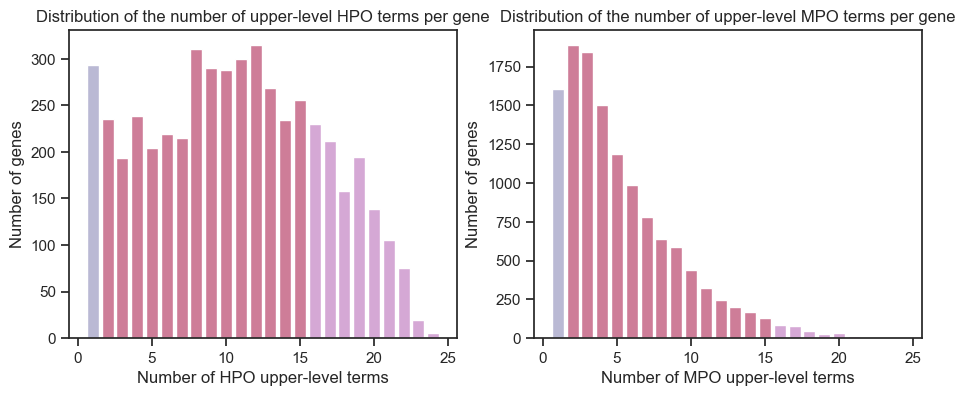

In [104]:
# looking at the distribution of the number of system HPO and MPO terms per gene

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# distribution of the number of system HPO terms per gene
grouped_hpo = main_HPO_table.groupby("HP_high_count")["gene_human"].count()

# Creating a color list
colors_hpo = ['#bab9d4'] + ['#ce7d98'] * 14 + ['#d5a8d5'] * 10 # create a colour scheme for colouring the columns by category

ax1.bar(grouped_hpo.index, grouped_hpo.values, color=colors_hpo[:len(grouped_hpo)])
ax1.set_xlabel("Number of HPO upper-level terms")
ax1.set_ylabel("Number of genes")
ax1.set_title("Distribution of the number of upper-level HPO terms per gene")

# distribution of the number of system MPO terms per gene
grouped_mpo = main_HPO_table.groupby("MP_high_count")["gene_mouse"].count()

# Using the same color list for MPO
ax2.bar(grouped_mpo.index, grouped_mpo.values, color=colors_hpo[:len(grouped_mpo)])
ax2.set_xlabel("Number of MPO upper-level terms")
ax2.set_ylabel("Number of genes")
ax2.set_title("Distribution of the number of upper-level MPO terms per gene")

plt.savefig(os.path.join('.', 'pictures', 'plei_08_distribution.png'), dpi=300)
plt.show()


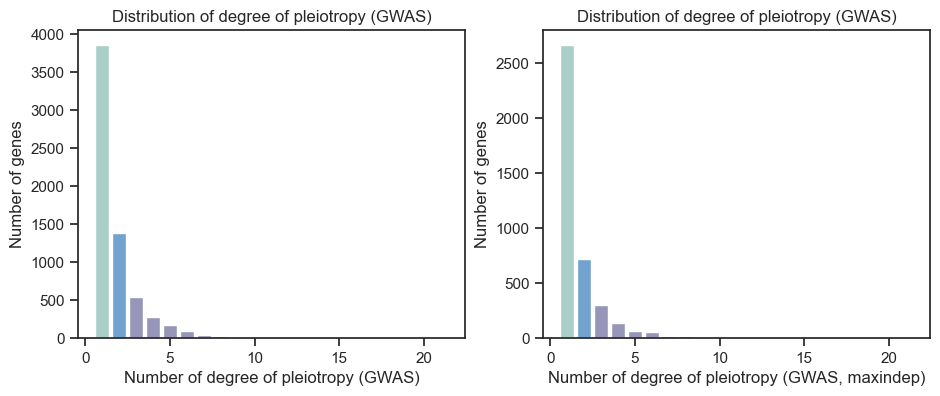

In [105]:
# looking at the distribution of degree of pleiotropy (GWAS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# distribution of the pleio_degree per gene
grouped_hpo = main_HPO_table.groupby("pleio_degree")["gene_human"].count()

# Creating a color list
colors = ['#aacfc9'] + ['#72a2ce'] * 1 + ['#9796b8'] * 26 # create a colour scheme for colouring the columns by category

ax1.bar(grouped_hpo.index, grouped_hpo.values, color=colors[:len(grouped_hpo)])
ax1.set_xlabel("Number of degree of pleiotropy (GWAS)")
ax1.set_ylabel("Number of genes")
ax1.set_title("Distribution of degree of pleiotropy (GWAS)")

# distribution of the number pleio_degree_maxindep per gene
grouped_mpo = main_HPO_table.groupby("pleio_degree_maxindep")["gene_human"].count()

# Using the same color list for MPO
ax2.bar(grouped_mpo.index, grouped_mpo.values, color=colors[:len(grouped_mpo)])
ax2.set_xlabel("Number of degree of pleiotropy (GWAS, maxindep)")
ax2.set_ylabel("Number of genes")
ax2.set_title("Distribution of degree of pleiotropy (GWAS)")

plt.savefig(os.path.join('.', 'pictures', 'plei_09_distribution.png'), dpi=300)
plt.show()

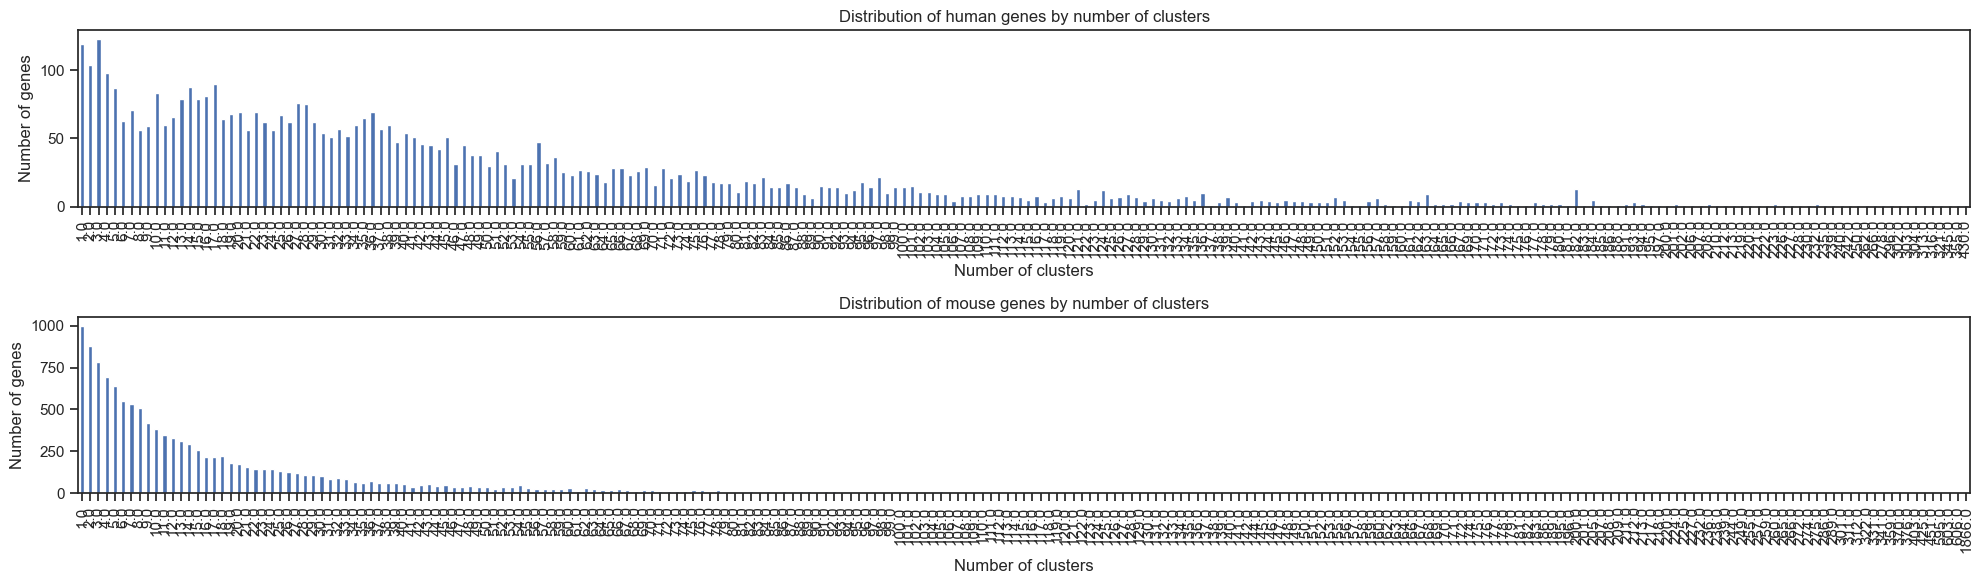

In [106]:
# looking at the distribution of clusters

human_cluster_counts = main_HPO_table['n_clusters_h'].value_counts().sort_index()
mouse_cluster_counts = main_HPO_table['n_clusters_m'].value_counts().sort_index()

plt.figure(figsize=(20, 6))

plt.subplot(2, 1, 1)
human_cluster_counts.plot(kind='bar')
plt.title('Distribution of human genes by number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Number of genes')

plt.subplot(2, 1, 2)
mouse_cluster_counts.plot(kind='bar')
plt.title('Distribution of mouse genes by number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Number of genes')

plt.tight_layout()

plt.savefig(os.path.join('.', 'pictures', 'plei_31_distribution_clusters.png'), dpi=300)
plt.show()


#### Expression level analysis
Analyse the expression level in different pleiotropy groups based on GTEx data.

In [107]:
# importing the GTEx table

gtex_data = pd.read_csv(os.path.join('.', 'databases', 'expression_GTEx.gct'),
                   delimiter='\t',
                   skiprows=2)
gtex_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56200 entries, 0 to 56199
Data columns (total 56 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Name                                       56200 non-null  object 
 1   Description                                56200 non-null  object 
 2   Adipose - Subcutaneous                     56200 non-null  float64
 3   Adipose - Visceral (Omentum)               56200 non-null  float64
 4   Adrenal Gland                              56200 non-null  float64
 5   Artery - Aorta                             56200 non-null  float64
 6   Artery - Coronary                          56200 non-null  float64
 7   Artery - Tibial                            56200 non-null  float64
 8   Bladder                                    56200 non-null  float64
 9   Brain - Amygdala                           56200 non-null  float64
 10  Brain - Anterior cingu

In [108]:
# adding new columns with median and average tissue expression 
gtex_data['median_exp'] = gtex_data.iloc[:, 2:55].median(axis=1)
gtex_data['mean_exp'] = gtex_data.iloc[:, 2:55].mean(axis=1)

# add new columns with the number of tissues with expression > 10
gtex_data['count_exp'] = gtex_data.iloc[:, 2:55].apply(lambda x: (x > 10).sum(), axis=1)

# adding new columns with maximum tissue expression 
gtex_data['max_exp'] = gtex_data.iloc[:, 2:55].max(axis=1)

In [109]:
#  look at the duplicates

duplicates = gtex_data[gtex_data.duplicated(subset=['Description'], keep=False)]
print(len(duplicates))

1807


In [110]:
# remove duplicates

duplicates = gtex_data[gtex_data.duplicated(subset=['Description'], keep=False)]

# remove duplicates with 0 expression related to _PAR_Y

for index, row in duplicates.iterrows():
    if (row['median_exp'] == 0) and (row['mean_exp'] == 0) and (row['count_exp'] == 0):
        gtex_data = gtex_data.drop(index)

# delete all duplicates with double ENSG

gtex_data.drop_duplicates(subset=['Description'], keep=False, inplace=True)

In [111]:
#  look at the duplicates

duplicates = gtex_data[gtex_data.duplicated(subset=['Description'], keep=False)]
print(len(duplicates))

0


#### Evolutionary conservation level analysis
Analyse the level of evolutionary conservatism in different pleiotropy groups based on gnomAD data.

In [112]:
# importing the gnomAD constraint table

gnomad_data = pd.read_csv(os.path.join('.', 'databases', 'constraint_gnomAD.txt'),
                   delimiter='\t')

gnomad_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19658 entries, 0 to 19657
Data columns (total 77 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gene                19658 non-null  object 
 1   transcript          19658 non-null  object 
 2   obs_mis             19658 non-null  int64  
 3   exp_mis             19658 non-null  float64
 4   oe_mis              19657 non-null  float64
 5   mu_mis              19658 non-null  float64
 6   possible_mis        19658 non-null  int64  
 7   obs_mis_pphen       19333 non-null  float64
 8   exp_mis_pphen       19333 non-null  float64
 9   oe_mis_pphen        19320 non-null  float64
 10  possible_mis_pphen  19333 non-null  float64
 11  obs_syn             19658 non-null  int64  
 12  exp_syn             19658 non-null  float64
 13  oe_syn              19657 non-null  float64
 14  mu_syn              19658 non-null  float64
 15  possible_syn        19658 non-null  int64  
 16  obs_

In [113]:
# determine the number of unique genes
unique_genes = gnomad_data['gene'].nunique()
print("Number of unique genes:", unique_genes)

# determine the number of duplicates
duplicate_genes = gnomad_data['gene'].duplicated().sum()
print("Number of duplicate genes:", duplicate_genes)

Number of unique genes: 19658
Number of duplicate genes: 0


In [114]:
# leave only the necessary parameters in the dataframe

gnomad_data = gnomad_data.loc[:, ['gene', 'oe_lof_upper', 'pLI', 'mis_z']]

#### Protein-protein interactions analysis 
Analyse protein-protein interactions and compare them using BIOGRID data.

In [115]:
# importing the BIOGRID table for human

biogrid_data = pd.read_csv(os.path.join('.', 'databases', 'biogrid_interaction_human.txt.gz'),
                   delimiter='\t', compression='gzip',
                   skiprows=35)
biogrid_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1158408 entries, 0 to 1158407
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   INTERACTOR_A         1158408 non-null  object
 1   INTERACTOR_B         1158408 non-null  object
 2   OFFICIAL_SYMBOL_A    1158408 non-null  object
 3   OFFICIAL_SYMBOL_B    1158408 non-null  object
 4   ALIASES_FOR_A        1158408 non-null  object
 5   ALIASES_FOR_B        1158408 non-null  object
 6   EXPERIMENTAL_SYSTEM  1158408 non-null  object
 7   SOURCE               1150074 non-null  object
 8   PUBMED_ID            1158408 non-null  int64 
 9   ORGANISM_A_ID        1158408 non-null  int64 
 10  ORGANISM_B_ID        1158408 non-null  int64 
dtypes: int64(3), object(8)
memory usage: 97.2+ MB


In [116]:
# importing the BIOGRID table for mice

biogrid_data_mice = pd.read_csv(os.path.join('.', 'databases', 'biogrid_interaction_mice.txt'),
                   delimiter='\t',
                   skiprows=35)
biogrid_data_mice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99242 entries, 0 to 99241
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   INTERACTOR_A         99242 non-null  object
 1   INTERACTOR_B         99242 non-null  object
 2   OFFICIAL_SYMBOL_A    99242 non-null  object
 3   OFFICIAL_SYMBOL_B    99242 non-null  object
 4   ALIASES_FOR_A        99242 non-null  object
 5   ALIASES_FOR_B        99242 non-null  object
 6   EXPERIMENTAL_SYSTEM  99242 non-null  object
 7   SOURCE               99242 non-null  object
 8   PUBMED_ID            99242 non-null  int64 
 9   ORGANISM_A_ID        99242 non-null  int64 
 10  ORGANISM_B_ID        99242 non-null  int64 
dtypes: int64(3), object(8)
memory usage: 8.3+ MB


In [117]:
# calculate the interactions for each gene for human

gene_interactions = {}

for _, row in biogrid_data.iterrows():
    gene_a = row['OFFICIAL_SYMBOL_A']
    gene_b = row['OFFICIAL_SYMBOL_B']
    
    if gene_a in gene_interactions:
        gene_interactions[gene_a]['interact'].add(gene_b)
        gene_interactions[gene_a]['n_interactions'] += 1
    else:
        gene_interactions[gene_a] = {
            'gene': gene_a,
            'interact': {gene_b},
            'n_interactions': 1
        }
    
    if gene_b in gene_interactions:
        gene_interactions[gene_b]['interact'].add(gene_a)
        gene_interactions[gene_b]['n_interactions'] += 1
    else:
        gene_interactions[gene_b] = {
            'gene': gene_b,
            'interact': {gene_a},
            'n_interactions': 1
        }

interactions_data = pd.DataFrame.from_dict(gene_interactions, orient='index')
interactions_data = interactions_data.reset_index(drop=True)

interactions_data

,gene,interact,n_interactions
0,MAP2K4,"{Flna, SH3RF3, APEX1, PRKCZ, FLNB, MAP3K1, MAP...",123
1,FLNC,"{IARS, FRYL, STAU1, KIF20A, PRKCZ, SNX24, TP63...",252
2,MYPN,"{KIF14, GBF1, ANKRD23, SSFA2, ANKRD1, NEBL, Mi...",40
3,ACTN2,"{SHANK3, ODF3B, KIF20A, LDB3, HTT, SPA17, CIT,...",187
4,ACVR1,"{Rab6b, Stat1, CIT, BMP7, Rab33b, Rap2a, SMAD7...",137
...,...,...,...
26852,SLC22A10,{SPPL3},1
26853,ZNF728,{SPPL3},1
26854,SHISA7,{SPPL3},1
26855,ZP1,{SPPL3},1


In [118]:
# calculate the interactions for each gene for mice

gene_interactions_mice = {}

for _, row in biogrid_data_mice.iterrows():
    # gene_a = row['OFFICIAL_SYMBOL_A']
    # gene_b = row['OFFICIAL_SYMBOL_B']
    gene_a = row['OFFICIAL_SYMBOL_A'][0] + row['OFFICIAL_SYMBOL_A'][1:].lower()
    gene_b = row['OFFICIAL_SYMBOL_B'][0] + row['OFFICIAL_SYMBOL_B'][1:].lower()
    
    if gene_a in gene_interactions_mice:
        gene_interactions_mice[gene_a]['interact_mice'].add(gene_b)
        gene_interactions_mice[gene_a]['n_interactions_mice'] += 1
    else:
        gene_interactions_mice[gene_a] = {
            'gene_mice': gene_a,
            'interact_mice': {gene_b},
            'n_interactions_mice': 1
        }
    
    if gene_b in gene_interactions_mice:
        gene_interactions_mice[gene_b]['interact_mice'].add(gene_a)
        gene_interactions_mice[gene_b]['n_interactions_mice'] += 1
    else:
        gene_interactions_mice[gene_b] = {
            'gene_mice': gene_b,
            'interact_mice': {gene_a},
            'n_interactions_mice': 1
        }

interactions_data_mice = pd.DataFrame.from_dict(gene_interactions_mice, orient='index')
interactions_data_mice  = interactions_data_mice .reset_index(drop=True)

#### Signs of positive selection analysis 
Analyse signs of positive selection using DRC150 and iHS data.

In [119]:
# importing the DRC150 table

drc_150 = pd.read_csv(os.path.join('.', 'databases', 'max_gene_DRC150.tsv'), delim_whitespace=True)
drc_150.columns = ['gene_name', 'max_drc_150']
drc_150

/tmp/ipykernel_10056/3984060618.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  drc_150 = pd.read_csv(os.path.join('.', 'databases', 'max_gene_DRC150.tsv'), delim_whitespace=True)


,gene_name,max_drc_150
0,7SK,0.001891
1,A1CF,0.001786
2,A2M,0.001704
3,A2ML1,0.001679
4,A2ML1-AS1,0.001601
...,...,...
21746,snoZ178,0.002271
21747,snoZ247,0.001722
21748,snoZ40,0.001701
21749,snoZ6,0.002089


In [120]:
# importing the IHS table
ihs = pd.read_csv(os.path.join( '.', 'databases', 'new_ihs_data.tsv'), delim_whitespace=True)
ihs.drop_duplicates('gene_name', inplace=True)
ihs

/tmp/ipykernel_10056/901134007.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ihs = pd.read_csv(os.path.join( '.', 'databases', 'new_ihs_data.tsv'), delim_whitespace=True)


,gene_name,iHS_GBR_max_500,iHS_snps_per_gene,pval_iHS_max,pval_iHS_max_fdr
0,DDX11L1,0.0,0.0,0.000000,NaN
1,WASH7P,0.0,4.0,0.937500,1.0
2,MIR1302-11,0.0,1.0,0.500000,1.0
3,FAM138A,0.0,0.0,0.000000,NaN
4,OR4G4P,0.0,10.0,0.999023,1.0
...,...,...,...,...,...
57844,CYCSP49,0.0,0.0,0.000000,NaN
57845,SLC25A15P1,0.0,0.0,0.000000,NaN
57846,PARP4P1,0.0,0.0,0.000000,NaN
57847,FAM58CP,0.0,0.0,0.000000,NaN


#### Dosage sensitivity analysis
Analyse dosage sensitivity using Collins RL et al. data.

In [121]:
# importing the DRC150 table

dos_sens_data = pd.read_csv(os.path.join('.', 'databases', 'dososage_sens.csv'))
dos_sens_data

,Gene,pHaplo,pTriplo,gnomAD_pLI,gnomAD_LOEUF,gnomAD_MisOEUF,ExAC_DEL_Z-Score,ExAC_DUP_Z-Score,ExAC_CNV_Z-Score,RVIS_Pct,HI_Index,sHet,CCDG_DEL_Score,CCDG_DUP_Score,Episcore,EDS
0,CREBBP,0.999,1.000,1.0,0.066,0.747,1.310,0.848,1.196,0.596,1.000,0.713,0.767,0.934,0.822,0.609
1,MED13L,0.999,1.000,1.0,0.064,0.741,0.818,-0.319,0.071,1.496,0.722,0.144,0.976,1.103,0.878,0.861
2,NSD1,0.999,1.000,1.0,0.095,0.785,1.442,0.955,1.314,1.134,0.565,0.237,0.906,0.856,0.881,0.566
3,ARHGEF12,0.999,1.000,1.0,0.179,0.733,1.640,1.409,1.759,4.633,0.389,0.098,0.882,1.174,0.851,0.692
4,CAMTA1,0.999,0.999,1.0,0.172,0.757,0.838,1.395,1.388,7.097,0.196,0.338,1.936,0.807,0.885,0.892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18636,OR4A16,0.002,0.002,0.0,1.881,1.954,NaN,NaN,NaN,60.196,0.115,0.003,NaN,NaN,0.022,0.257
18637,OR5M11,0.001,0.023,0.0,1.833,1.252,-0.340,-0.983,-0.850,85.024,NaN,NaN,0.414,0.429,0.001,0.358
18638,OR11H4,0.000,0.008,0.0,1.905,1.417,-0.540,-1.287,-1.056,68.045,0.062,NaN,-2.892,-2.999,0.004,0.317
18639,OR5M3,0.000,0.025,0.0,1.919,1.352,-0.944,-0.822,-0.936,95.630,0.118,NaN,0.414,0.429,0.001,0.264


#### Conservation scores analysis
Analyse conservation scores using phastCons data

In [122]:
# importing the phastCons table

phast_cons_data = pd.read_csv(os.path.join('.', 'databases', 'phastCons_average.tsv'), delim_whitespace=True)
phast_cons_data.columns = ['gene', 'phast_cons']
phast_cons_data

/tmp/ipykernel_10056/620077861.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  phast_cons_data = pd.read_csv(os.path.join('.', 'databases', 'phastCons_average.tsv'), delim_whitespace=True)


,gene,phast_cons
0,DDX11L1,0.105669
1,WASH7P,0.060497
2,MIR1302-11,0.037335
3,FAM138A,0.048410
4,OR4G4P,0.077379
...,...,...
57855,IL9R,0.060365
57856,AJ271736.10,0.079113
57857,WASIR1,0.069377
57858,WASH6P,0.136902


In [123]:
pc_cds_data = pd.read_csv(os.path.join('.', 'databases', 'phastCons_cds_averages.tsv'), delim_whitespace=True)
pc_cds_data = pc_cds_data.drop(['score', 'length'], axis=1)
pc_cds_data.columns = ['gene', 'phastcons_cds']
pc_cds_data

/tmp/ipykernel_10056/123077204.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pc_cds_data = pd.read_csv(os.path.join('.', 'databases', 'phastCons_cds_averages.tsv'), delim_whitespace=True)


,gene,phastcons_cds
0,A1BG,0.073572
1,A1CF,0.287554
2,A2M,0.312511
3,A2ML1,0.314993
4,A3GALT2,0.356141
...,...,...
19671,ZYX,0.303294
19672,ZZEF1,0.313679
19673,ZZZ3,0.268457
19674,hsa-mir-1199,0.228435


### Getting gene length information from GENCODE v19

In [124]:
gencode_gene_data = pd.read_csv('./databases/gencode.v19.genes.bed', sep='\t', header=None)
gencode_gene_data.columns = ['chr', 'start', 'end', 'gene_symbol']
gencode_gene_data.head()

,chr,start,end,gene_symbol
0,1,11868,14412,DDX11L1
1,1,14362,29806,WASH7P
2,1,29553,31109,MIR1302-11
3,1,34553,36081,FAM138A
4,1,52472,54936,OR4G4P


In [125]:
gencode_gene_data['gene_length'] = [y - x for x, y in zip(gencode_gene_data['start'], gencode_gene_data['end'])]
gencode_gene_data.drop(['chr', 'start', 'end'], axis=1, inplace=True)
gencode_gene_data.head()

,gene_symbol,gene_length
0,DDX11L1,2544
1,WASH7P,15444
2,MIR1302-11,1556
3,FAM138A,1528
4,OR4G4P,2464


In [126]:
gencode_gene_data.shape

(57820, 2)

In [127]:
gencode_gene_data.drop_duplicates('gene_symbol', inplace=True)
gencode_gene_data.shape

(55765, 2)

Performing the same operations for the mouse genome annotation

In [128]:
gencode_mouse_gene_data = pd.read_csv('./databases/gencode.vM37.genes.bed', sep='\t', header=None)
gencode_mouse_gene_data.columns = ['chr', 'start', 'end', 'gene_symbol_mouse']
gencode_mouse_gene_data.head()

,chr,start,end,gene_symbol_mouse
0,1,3143475,3144545,4933401J01Rik
1,1,3172238,3172348,Gm26206
2,1,3276123,3741721,Xkr4
3,1,3322979,3323459,Gm18956
4,1,3435953,3438772,Gm37180


In [129]:
gencode_mouse_gene_data['gene_length_mouse'] = [y - x for x, y in zip(gencode_mouse_gene_data['start'], 
                                                                gencode_mouse_gene_data['end'])]
gencode_mouse_gene_data.drop(['chr', 'start', 'end'], axis=1, inplace=True)
gencode_mouse_gene_data.head()

,gene_symbol_mouse,gene_length_mouse
0,4933401J01Rik,1070
1,Gm26206,110
2,Xkr4,465598
3,Gm18956,480
4,Gm37180,2819


In [130]:
gencode_mouse_gene_data.shape

(78258, 2)

In [131]:
gencode_mouse_gene_data.drop_duplicates('gene_symbol_mouse', inplace=True)
gencode_mouse_gene_data.shape

(77942, 2)

### Updated $s_{het}$ estimates from Zeug et al., 2024

In [132]:
ensg_to_symbol = pd.read_csv('./databases/ensg_to_symbol.tsv', sep='\t', header=None)
ensg_to_symbol.columns = ['ensg', 'symbol']
ensg_to_symbol.head()

,ensg,symbol
0,ENSG00000223972,DDX11L1
1,ENSG00000227232,WASH7P
2,ENSG00000243485,MIR1302-11
3,ENSG00000237613,FAM138A
4,ENSG00000268020,OR4G4P


In [133]:
zeug_data = pd.read_csv('./databases/zeug_shet.tsv', sep='\t')
zeug_data.head()

,ensg,hgnc,chrom,obs_lof,exp_lof,prior_mean,post_mean,post_lower_95,post_upper_95
0,ENSG00000198488,HGNC:24141,chr11,12.0,8.9777,0.001997,0.000065,0.000007,0.000178
1,ENSG00000164363,HGNC:26441,chr5,31.0,28.5500,0.000973,0.000161,0.000026,0.000442
2,ENSG00000159337,HGNC:30038,chr15,28.0,41.8400,0.000856,0.000170,0.000019,0.000533
3,ENSG00000177558,HGNC:26366,chr19,12.0,9.9101,0.001040,0.000175,0.000025,0.000487
4,ENSG00000062524,HGNC:6721,chr15,40.0,42.6820,0.002000,0.000180,0.000012,0.000589


In [134]:
zeug_data = zeug_data.merge(ensg_to_symbol, on='ensg')
zeug_data.head()

,ensg,hgnc,chrom,obs_lof,exp_lof,prior_mean,post_mean,post_lower_95,post_upper_95,symbol
0,ENSG00000198488,HGNC:24141,chr11,12.0,8.9777,0.001997,0.000065,0.000007,0.000178,B3GNT6
1,ENSG00000164363,HGNC:26441,chr5,31.0,28.5500,0.000973,0.000161,0.000026,0.000442,SLC6A18
2,ENSG00000159337,HGNC:30038,chr15,28.0,41.8400,0.000856,0.000170,0.000019,0.000533,PLA2G4D
3,ENSG00000177558,HGNC:26366,chr19,12.0,9.9101,0.001040,0.000175,0.000025,0.000487,FAM187B
4,ENSG00000062524,HGNC:6721,chr15,40.0,42.6820,0.002000,0.000180,0.000012,0.000589,LTK


In [135]:
zeug_data.drop(['ensg', 'hgnc', 'chrom', 'obs_lof', 'exp_lof', 'prior_mean', 'post_lower_95', 'post_upper_95'],
               axis=1, inplace=True)
zeug_data.columns = ['shet', 'symbol']
zeug_data.head()

,shet,symbol
0,0.000065,B3GNT6
1,0.000161,SLC6A18
2,0.000170,PLA2G4D
3,0.000175,FAM187B
4,0.000180,LTK


### Adding essential gene annotations from FUSIL

In [136]:
fusil_df = pd.read_csv('./databases/FUSIL.txt', sep='\t')
fusil_df.head()

,HGNC_ID,MGI_ID,IMPC_adult_viability,IMPC_embryo_viability,Avana_mean,Avana_mean_045,IMPC_Viability,adHOM_top_level_mp_name,adHEMI_top_level_mp_name,Viable_Phenotypes_updated,FUSIL_outliers,FUSIL
0,HGNC:10001,MGI:1098434,Viable,InsuffData/NoData,0.020186795,Non-essential,Viable,-,-,Viable_nophenotype,VN,VN
1,HGNC:10007,MGI:2384891,Lethal,Lethal_E9.5,-0.166498627,Non-essential,Lethal,mortality/aging,-,-,DL,DL
2,HGNC:10009,MGI:1202882,Viable,InsuffData/NoData,0.103437708,Non-essential,Viable,hematopoietic system phenotype|homeostasis/met...,-,Viable_phenotype,VP,VP
3,HGNC:10021,MGI:2154952,Viable,InsuffData/NoData,-0.243978281,Non-essential,Viable,integument phenotype,-,Viable_phenotype,VP,VP
4,HGNC:10024,MGI:97930,Viable,InsuffData/NoData,0.001122756,Non-essential,Viable,-,-,Viable_nophenotype,VN,VN


### Creating a general dataframe

In [143]:
# function to combine multiple dataframes
def merge_dataframes(main_df, merge_info):
    merge_counter = 0
    for info in merge_info:
        main_df = main_df.merge(info['df'], how='outer', left_on=info['left_on'], right_on=info['right_on'],
                               suffixes=[f'_{merge_counter * 2}', f'_{merge_counter * 2 + 1 }'])
        merge_counter += 1
    return main_df

# list and connection parameters
merge_info = [
    {'df': gtex_data, 'left_on': 'gene_human', 'right_on': 'Description'},
    {'df': gnomad_data, 'left_on': 'gene_human', 'right_on': 'gene'},
    {'df': interactions_data, 'left_on': 'gene_human', 'right_on': 'gene'},
    {'df': interactions_data_mice, 'left_on': 'gene_human', 'right_on': 'gene_mice'},
    {'df': drc_150, 'left_on': 'gene_human', 'right_on': 'gene_name'},
    {'df': ihs, 'left_on': 'gene_human', 'right_on': 'gene_name'},
    {'df': dos_sens_data, 'left_on': 'gene_human', 'right_on': 'Gene'},
    {'df': phast_cons_data, 'left_on': 'gene_human', 'right_on': 'gene'},
    {'df': pc_cds_data, 'left_on': 'gene_human', 'right_on': 'gene'},
    {'df': gencode_gene_data, 'left_on': 'gene_human', 'right_on': 'gene_symbol'},
    {'df': gencode_mouse_gene_data, 'left_on': 'gene_mouse', 'right_on': 'gene_symbol_mouse'},
    {'df': zeug_data, 'left_on': 'gene_human', 'right_on': 'symbol'},
    {'df': fusil_df, 'left_on': 'MGI', 'right_on': 'MGI_ID'}
]

# combination
general_HPO_table = merge_dataframes(main_HPO_table, merge_info)

general_HPO_table.shape

(246994, 136)

In [138]:
# [x for x in general_HPO_table.columns if 'gene_name' in x]

In [144]:
general_HPO_table = general_HPO_table.dropna(subset=['gene_human', 'gene_mouse'], how='all')
general_HPO_table.shape

(32624, 136)

In [145]:
# selecting the required columns
selected_columns = [
    'gene_human', 'entrez_id_human', 'gene_mouse', 'MGI', 'entrez_id_mouse',
    'MP_low_level', 'HP_low_level', 'MP_high_level', 'HP_high_level_human', 'HP_high_level', 
    'HP_count', 'HP_high_count', 'MP_count', 'MP_high_count', 
    'pleio_degree', 'pleio_degree_maxindep', 'pleio_degree_locuswide', 'fg_pleio_degree', 'fg_pleio_degree_finemap',
    'median_exp', 'mean_exp', 'count_exp', 'max_exp', 'gene_length', 'gene_length_mouse',
    'oe_lof_upper', 'pLI', 'mis_z', 'shet',
    'interact', 'n_interactions', 'interact_mice', 'n_interactions_mice',
    'max_drc_150', 'iHS_GBR_max_500', 'iHS_snps_per_gene', 'pval_iHS_max', 'pval_iHS_max_fdr',
    'pHaplo', 'pTriplo', 'FUSIL',
    'phast_cons', 'phastcons_cds',
    'n_clusters_h', 'n_clusters_m'
]
general_HPO_table = general_HPO_table.loc[:, selected_columns]

general_HPO_table = general_HPO_table[(~general_HPO_table.duplicated('gene_human')) | (general_HPO_table['gene_human'].isnull())]
general_HPO_table = general_HPO_table[(~general_HPO_table.duplicated('gene_mouse')) | (general_HPO_table['gene_mouse'].isnull())]
# saving
output_path = os.path.join('.', 'updated_general_HPO_table.tsv')
general_HPO_table.to_csv(output_path, sep='\t', index=False)

general_HPO_table

,gene_human,entrez_id_human,gene_mouse,MGI,entrez_id_mouse,MP_low_level,HP_low_level,MP_high_level,HP_high_level_human,HP_high_level,...,iHS_snps_per_gene,pval_iHS_max,pval_iHS_max_fdr,pHaplo,pTriplo,FUSIL,phast_cons,phastcons_cds,n_clusters_h,n_clusters_m
0,CFL1,1072,Cfl1,MGI:101757,NaN,"[MP:0012706, MP:0000930, MP:0002151, MP:000295...",None,"[MP:0005391, MP:0005378, MP:0005380, MP:000363...",None,None,...,265.0,0.303375,1.000000,0.351,0.902,NaN,0.123029,0.299264,NaN,50.0
1,SYT4,6860,Syt4,MGI:101759,NaN,"[MP:0001469, MP:0010088, MP:0005419, MP:000140...",None,"[MP:0005386, MP:0005376]",None,None,...,62.0,0.992451,1.000000,0.341,0.247,NaN,0.160200,0.288837,NaN,8.0
2,SFSWAP,6433,Sfswap,MGI:101760,NaN,"[MP:0002941, MP:0003491, MP:0010506, MP:000533...",None,"[MP:0005377, MP:0005376, MP:0005386, MP:0005385]",None,None,...,626.0,0.274983,1.000000,0.946,0.700,NaN,0.039070,0.320636,NaN,6.0
3,HMGA2,8091,Hmga2,MGI:101761,NaN,"[MP:0008974, MP:0001924, MP:0001402, MP:000001...","[HP:0000664, HP:0002714, HP:0002579, HP:000008...","[MP:0005377, MP:0010771, MP:0005386, MP:000538...","[HP:0000234, HP:0011968, HP:0000079, HP:000150...","[MP:0005386, MP:0005391, MP:0003631, MP:000537...",...,865.0,1.000000,1.000000,0.855,0.481,NaN,0.105724,0.070630,69.0,58.0
4,ELK3,2004,Elk3,MGI:101762,NaN,"[MP:0000249, MP:0001544, MP:0001402, MP:001082...",None,"[MP:0005388, MP:0005376, MP:0005387, MP:000538...",None,None,...,454.0,0.999990,1.000000,0.778,0.416,NaN,0.060484,0.281814,NaN,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34439,snoU109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.0,0.996094,1.000000,NaN,NaN,NaN,0.624622,NaN,NaN,NaN
34446,snoU13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0,0.993971,1.000000,NaN,NaN,NaN,0.017689,NaN,NaN,NaN
34911,snoZ40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.0,0.001262,0.009849,NaN,NaN,NaN,0.001681,NaN,NaN,NaN
34912,snoZ6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,0.678961,1.000000,NaN,NaN,NaN,0.047360,NaN,NaN,NaN


In [146]:
shutil.copyfile('./updated_general_HPO_table.tsv', '../updated_general_HPO_table.tsv')

'../updated_general_HPO_table.tsv'

In [147]:
general_HPO_table['fg_pleio_degree'].sum()

np.float64(14898.0)